In [9]:
import pandas as pd
import matplotlib.pyplot as plt

In [10]:
df=pd.read_excel('Computer_Science_IX_Topicss.xlsx')

In [11]:
df.head()

,Year,Topic_id,Topic,Appeared,Chapter_Name
0,2024,U1-1,Computer Evolution,0,Fundamental of Computer
1,2024,U1-2,History and Generations of Computers,0,Fundamental of Computer
2,2024,U1-3,Types of Computers,1,Fundamental of Computer
3,2024,U1-4,Classification of Digital Computers,0,Fundamental of Computer
4,2024,U1-5,Uses of Computers in different fields,0,Fundamental of Computer


In [12]:
df = df.sort_values(['Topic', 'Year']).reset_index(drop=True)
df.head()

,Year,Topic_id,Topic,Appeared,Chapter_Name
0,2022,U1-16,Application Software,0,Fundamental of Computer
1,2023,U1-16,Application Software,0,Fundamental of Computer
2,2024,U1-16,Application Software,0,Fundamental of Computer
3,2025,U1-16,Application Software,0,Fundamental of Computer
4,2022,U6-12,Areas of Computer Ethics,1,Computer Security and Ethics


In [13]:
total_years = df['Year'].nunique()

freq = (df.groupby('Topic')['Appeared'].sum() / total_years).rename('Appearance_Rate')

last_seen = (df[df['Appeared'] == 1]
             .groupby('Topic')['Year'].max()
             .rename('Last_Seen'))

max_year = df['Year'].max()

ranking = pd.DataFrame(freq).join(last_seen)
ranking['Gap'] = max_year - ranking['Last_Seen']
ranking['Gap'] = ranking['Gap'].fillna(999)

topic_id_map = df[['Topic','Topic_id']].drop_duplicates().set_index('Topic')['Topic_id']
ranking = ranking.join(topic_id_map)

ranking['Score'] = ranking['Appearance_Rate'] - (ranking['Gap'] / ranking['Gap'].max()) * 0.3
ranking = ranking.sort_values('Score', ascending=False).reset_index()
ranking['Rank'] = ranking.index + 1
ranking.head(15)

,Topic,Appearance_Rate,Last_Seen,Gap,Topic_id,Score,Rank
0,Editing Text,1.00,2025.0,0.0,U3-3,1.0000,1
1,Components of a Communication System,1.00,2025.0,0.0,U4-2,1.0000,2
2,Modes of Data Communication,0.75,2025.0,0.0,U4-4,0.7500,3
3,Computer Crime Terminologies,0.75,2025.0,0.0,U6-2,0.7500,4
4,Basics of Spreadsheet,0.75,2025.0,0.0,U3-15,0.7500,5
5,Unguided Transmission Media,0.75,2025.0,0.0,U4-7,0.7500,6
6,Word Processor,0.75,2025.0,0.0,U3-1,0.7500,7
7,Data Transmission Modes,0.75,2024.0,1.0,U5-3,0.7497,8
8,"Ports, Expansion Slots and Expansion Card",0.50,2025.0,0.0,U1-12,0.5000,9
9,Basic Icons of GUI Operating System,0.50,2025.0,0.0,U2-6,0.5000,10


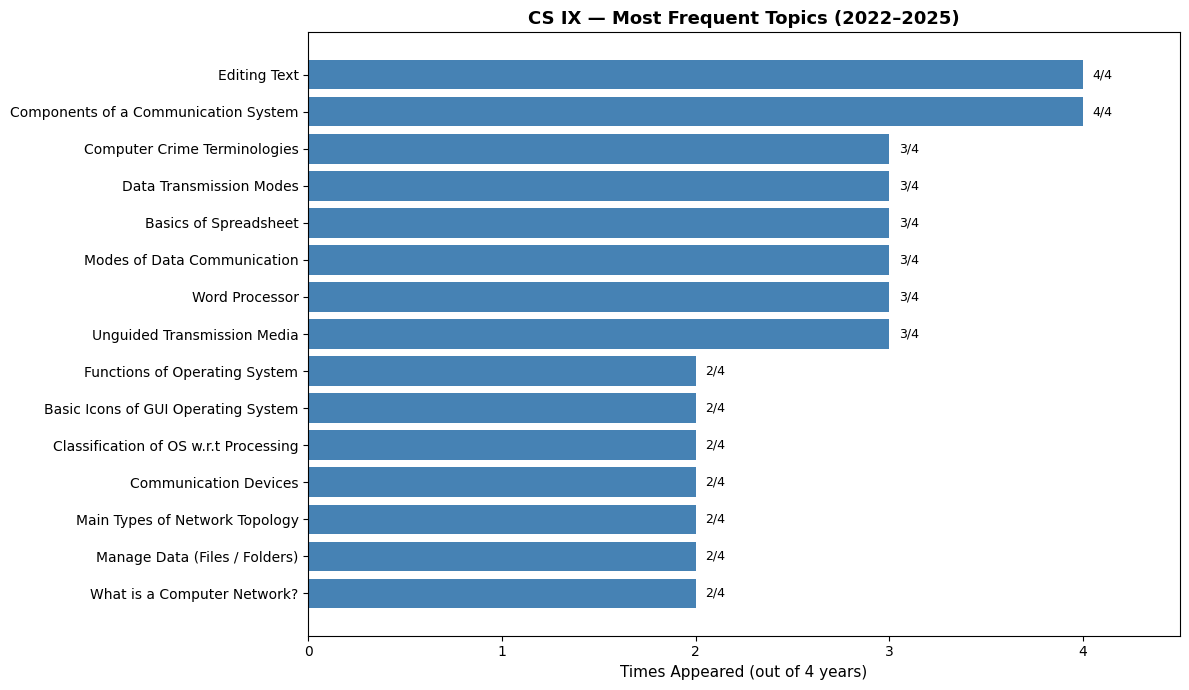

In [14]:
total_appearances = df.groupby('Topic')['Appeared'].sum().sort_values(ascending=False)
top15 = total_appearances.head(15)

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(top15.index[::-1], top15.values[::-1], color='steelblue')

for bar, val in zip(bars, top15.values[::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val}/{total_years}', va='center', fontsize=9)

ax.set_xlabel('Times Appeared (out of 4 years)', fontsize=11)
ax.set_title('CS IX — Most Frequent Topics (2022–2025)', fontsize=13, fontweight='bold')
ax.set_xlim(0, total_years + 0.5)
ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
plt.tight_layout()
plt.savefig('cs_graph1_frequency.png', dpi=150)
plt.show()

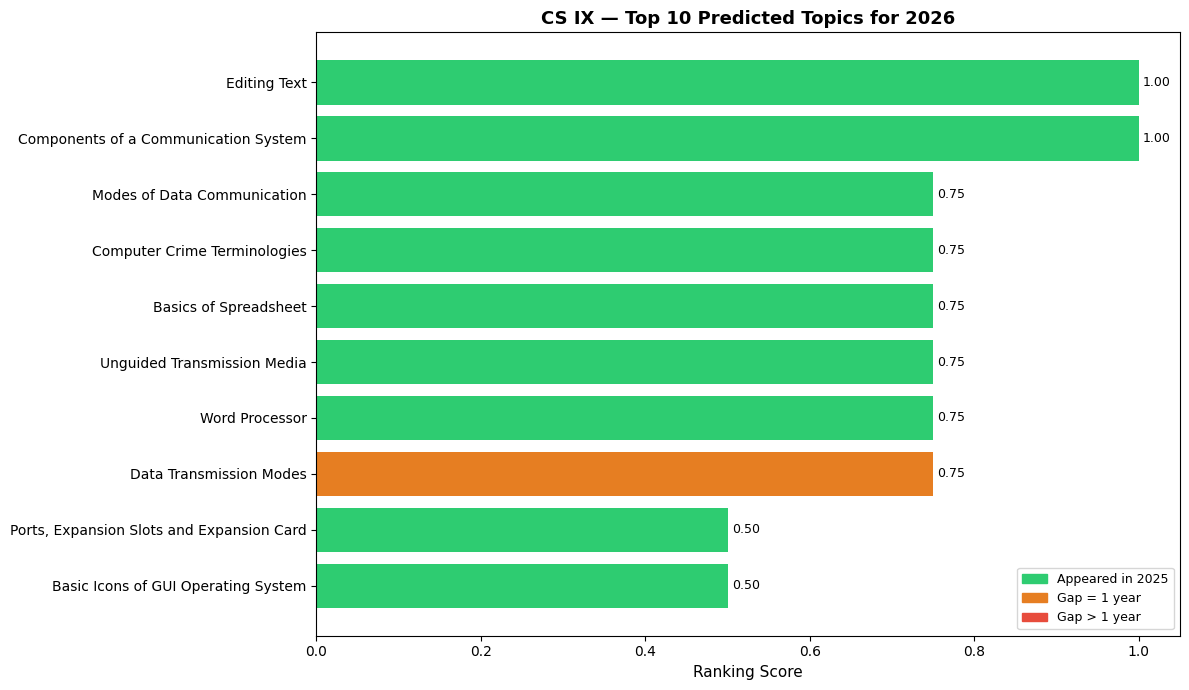

In [15]:
from matplotlib.patches import Patch

top10 = ranking.head(10)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#2ecc71' if g == 0 else '#e67e22' if g == 1 else '#e74c3c'
          for g in top10['Gap']]
bars = ax.barh(top10['Topic'][::-1], top10['Score'][::-1], color=colors[::-1])

for bar, val in zip(bars, top10['Score'][::-1]):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9)

ax.set_xlabel('Ranking Score', fontsize=11)
ax.set_title('CS IX — Top 10 Predicted Topics for 2026', fontsize=13, fontweight='bold')

legend = [Patch(color='#2ecc71', label='Appeared in 2025'),
          Patch(color='#e67e22', label='Gap = 1 year'),
          Patch(color='#e74c3c', label='Gap > 1 year')]
ax.legend(handles=legend, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('cs_graph2_predictions.png', dpi=150)
plt.show()

In [16]:
# Chapter map karo df se
topic_chapter_map = df[['Topic', 'Chapter_Name']].drop_duplicates().set_index('Topic')['Chapter_Name'].to_dict()

appeared_years_list = []
for _, row in ranking.head(25).iterrows():
    topic = row['Topic']
    years = df[
        (df['Topic'] == topic) &
        (df['Appeared'] == 1)
    ]['Year'].tolist()
    appeared_years_list.append(', '.join(map(str, sorted(years))))

final_ranking = ranking.head(25).copy()
final_ranking['Chapter_Name'] = final_ranking['Topic'].map(topic_chapter_map)
final_ranking['Years_Appeared'] = appeared_years_list
final_ranking['Total_Appearances'] = final_ranking['Years_Appeared'].apply(
    lambda x: len(x.split(', ')) if x else 0
)
final_ranking['Category'] = final_ranking['Score'].apply(
    lambda x: 'A - Must Prepare' if x >= 0.7 else 'B - Should Prepare'
)

final_ranking = final_ranking[['Topic_id', 'Topic', 'Chapter_Name', 'Score', 'Category', 'Years_Appeared', 'Total_Appearances']]\
    .rename(columns={'Score': 'Probability'})

final_ranking.to_excel('CS_9th_Predictions_2026.xlsx', index=False)
print(final_ranking)

   Topic_id                                      Topic  \
0      U3-3                               Editing Text   
1      U4-2       Components of a Communication System   
2      U4-4                Modes of Data Communication   
3      U6-2               Computer Crime Terminologies   
4     U3-15                      Basics of Spreadsheet   
5      U4-7                Unguided Transmission Media   
6      U3-1                             Word Processor   
7      U5-3                    Data Transmission Modes   
8     U1-12  Ports, Expansion Slots and Expansion Card   
9      U2-6        Basic Icons of GUI Operating System   
10     U1-3                         Types of Computers   
11     U4-9                      Communication Devices   
12     U5-8             Main Types of Network Topology   
13    U3-17              Representing Data Graphically   
14    U1-15                            System Software   
15     U2-2              Functions of Operating System   
16    U1-11   